## Installing uv

To start, you'll want to have uv installed:

https://docs.astral.sh/uv/getting-started/installation/


**Next, run this in the terminal, from the parent directory:**

    uv sync


Now you will have the kernel used to run this notebook

---

## Running the Required Servers

You need to run **three servers**, each in its own terminal:

- `central_server.py`
- `AS_server_SimAtomRes.py`
- `Ceos_server_twin.py`

### 1. Activate the Virtual Environment

`uv` should have created a `.venv` directory for you.

**On macOS / Linux:**

    source .venv/bin/activate

**On Windows (likely):**

    source .venv/Scripts/activate

You should now see the environment activated.

---

### 2. Start the Servers

**Terminal 1 — Central Server**

    source .venv/bin/activate
    python -m asyncroscopy.servers.protocols.central_server

**Terminal 2 — Atom Resolution Simulation Server**

    source .venv/bin/activate
    python -m asyncroscopy.servers.AS_server_SimAtomRes

**Terminal 3 — CEOS Twin Server**

    source .venv/bin/activate
    python -m asyncroscopy.servers.Ceos_server_twin

---

You're now ready to run this notebook! 🚀

In [1]:
import sys
import ast
# sys.path.insert(0, '../')
from asyncroscopy.clients.notebook_client import NotebookClient
import matplotlib.pyplot as plt

import pyTEMlib
from pyTEMlib import probe_tools as pt

### Connections:

In [2]:
# Connect the Client to the central (async) server
tem = NotebookClient.connect(host='localhost',port=9000)

# Tell the central server address of all connected instruments
routing_table= {"AS": ("localhost", 9001),
                "Gatan": ("localhost", 9002),
                "Ceos": ("localhost", 9003),
                "Preacquired_AS": ("localhost", 9004)}
tem.send_command('Central',"set_routing_table", routing_table)

# ConnectionResetError: [Errno 54] Connection reset by peer 
# in terminal, type:
# lsof -i :9000

Connecting to central server localhost:9000...
Connected to central server.


'[Central] Routing table updated'

In [3]:
# connect to the AutoScript computer and initialize microscope
# tem.send_command('AS',command='connect_AS',args={'host':'localhost','port':9001})
tem.send_command('AS',command='connect_AS',args={'host':'10.41','port':9001})

'Connected to Digital Twin microscope.'

In [4]:
tem.send_command(destination = 'Ceos', command = 'getInfo', args = {})

'CEOS Digital Twin Server'

### Help commands:

In [5]:
# Now that we're routed to all instruments,
# let's take an inventory of commands available on each instrument
cmds = tem.send_command('AS', 'discover_commands')
print(cmds)

["connect_AS", "connectionLost", "connectionMade", "dataReceived", "disconnect", "discover_commands", "get_help", "get_scanned_image", "get_stage", "get_status", "lengthLimitExceeded", "logPrefix", "makeConnection", "pauseProducing", "resumeProducing", "sendString", "set_current", "stopProducing", "stringReceived"]


In [6]:
# These two are working, but should be much better.
tem.send_command('AS', command='get_help', args={'command_name':'connect_AS'})

'{"name": "connect_AS", "signature": "(args: dict)", "summary": "Connect to the microscope via AutoScript", "doc": "Connect to the microscope via AutoScript"}'

### Setting the aberrations from known values:

In [7]:
aberrations = pt.get_target_aberrations("Spectra300", 60000)
tem.send_command(destination = 'Ceos', command = 'uploadAberrations', args = aberrations)
pt.print_aberrations(aberrations)

In [8]:
aberrations 

{'C10': 0,
 'C12a': 0,
 'C12b': 0.38448128113770325,
 'C21a': -68.45251255685642,
 'C21b': 64.85359774641199,
 'C23a': 11.667578600494137,
 'C23b': -29.775627778458194,
 'C30': 123,
 'C32a': 95.3047364258614,
 'C32b': -189.72105710231244,
 'C34a': -47.45099594807912,
 'C34b': -94.67424667529909,
 'C41a': -905.31842572806,
 'C41b': 981.316128853203,
 'C43a': 4021.8433526960034,
 'C43b': 131.72716642732158,
 'C45a': -4702.390968272048,
 'C45b': -208.25028574642903,
 'C50': 552000.0,
 'C52a': -0.0,
 'C52b': 0.0,
 'C54a': -0.0,
 'C54b': -0.0,
 'C56a': -36663.643489934424,
 'C56b': 21356.079837905396,
 'acceleration_voltage': 200000,
 'FOV': 34.241659495148205,
 'Cc': 1000000.0,
 'convergence_angle': 30,
 'wavelength': 0.0025079340450548005}

In [9]:
# at any time, we can view the current aberrations
# this should be implemented in the real ceos server as well
ab = tem.send_command(destination = 'Ceos', command = 'getAberrations', args={})
ab = ast.literal_eval(ab)
pt.print_aberrations(ab)

### Get an image:

simulated with pystemsim inside the AS_server_SimAtomRes (working with the Ceos server)

In [11]:
beam_current = 100
tem.send_command('AS', 'set_current', {'beam_current':beam_current}) # pA

'Beam current set to 100 pA'

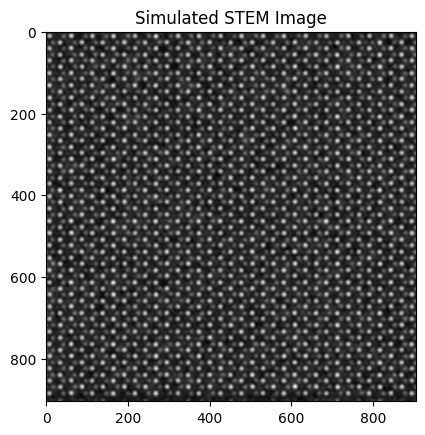

In [12]:
# tem.send_command('AS',"set_current", 1)
image_args = {'scanning_detector':'HAADF',
                'size':512,
                'dwell_time':10e-6}

img = tem.send_command('AS','get_scanned_image', image_args)

plt.imshow(img, cmap="gray")
plt.title("Simulated STEM Image")
plt.show()


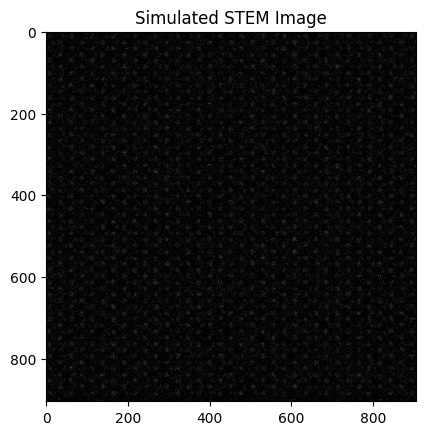

In [15]:
# tem.send_command('AS',"set_current", 1)
image_args = {'scanning_detector':'HAADF',
                'size':512,
                'dwell_time':0.001e-6}

img = tem.send_command('AS','get_scanned_image', image_args)

plt.imshow(img, cmap="gray")
plt.title("Simulated STEM Image")
plt.show()


### How it's actually working:
![Structure Diagram](../DT_workflow.png)

### try changing an aberration

In [ ]:
tem.send_command(destination = 'Ceos', command = 'correctAberration', args = {"name": 'C10', "value": -6})

In [ ]:
image_args = {'scanning_detector':'HAADF',
                'size':512,
                'dwell_time':10e-6}

img = tem.send_command('AS','get_scanned_image', image_args)

plt.imshow(img, cmap="gray")
plt.title("Simulated STEM Image")
plt.show()